# CobraBox Tutorial :: Exploring and Fetching Remote Datasets

Authors: *[COBRA group](https://cobra.cs.cas.cz), Institute of Computer Science, The Czech Academy of Sciences*

<div align="left">
<img src="Images/Logo_CAS_ICS.png" align="left" width="254" alt="logo ICS">
</div>


<br>
<br>

---------------------

This tutorial notebook illustrates the built-in capabilities of CobraBox to explore, access and fetch datasets from open-data repositories, and load them into the [native CobraBox data format](#). 

#### Contents of this tutorial

1. About curated datasets in CobraBox.
2. Getting information and loading a dataset.
3. ... FIX FROM HERE
4. Patient metadata
5. Loading the raw recordings
6. The raw signal in the time domain
7. Power-line filtering (50 Hz notch)
8. The bipolar montage
9. Where to go next …


### Import dependencies

Before getting started, we make sure all necessary packages are loaded. Running this notebook requires ***python*** (>=3.11) together with ***numpy*** (>=2.4.2), ***xarray*** (>2026.2.0) and ***cobrabox*** (>=1.0). These should have been automatically updated together with the ***cobrabox*** installation. Usually typing `pip install cobrabox` will install CobraBox and all its dependencies in the corresponding environment. Please visit the [CobraBox documentation](#) for further installation instructions. 

For the visualizations the notebook additionally requires ***Matplotlib***.


In [3]:
## IMPORT THE PACKAGES NEED TO RUN THE NOTEBOOK
# Python standard library imports
from pathlib import Path

# Third-party imports
import matplotlib.pyplot as plt
%matplotlib inline
import xarray as xr
import numpy as np
#from scipy.signal import filtfilt, iirnotch
import cobrabox as cb

# Local libraries and modules


In [4]:
# Set the local path to store the data
cb.set_dataset_dir(Path(".") / "data", persist=False)

Dataset directory set to: data


## 1. Curated datasets in CobraBox

Besides the extensive signal analysis features, CobraBox can import datasets from various formats and expose them. It uses native data structures based on the [***xarray*** package](https://docs.xarray.dev/en/stable/), which extends ***numpy*** for multidimensional labelled data. In general, users may import their own dataset and translate it into the CobraBox data structure (see Tutorial [Loading your Data](#) ). 

However, CobraBox also offers the possibility to load a number of previously curated datasets, ready to explore and use in the native data structure. The following functions allow for this:

- `cb.list_datasets()`
- `cb.show_datasets()`
- `cb.dataset_info()`
- `cb.load_dataset()`
- …

We distinguish between *local* and *remote* datasets:

- ***local datasets*** refer to datasets stored in the official CobraBox GitHub repository (see the ['Data/' folder](https://github.com/cobragroup/cobrabox/tree/main/data)). These usually correspond to simulated and sample signals, ready for loading and exploring.
- ***remote datasets*** are selected datasets, publicly available in open-data repositories, that can be directly loaded into CobraBox. Individual loader pipelines were developed for each of the datasets.

> ADDING DATASETS: Users can develop and contribute their own pipelines for the loading of specific datasets ([instructions here](#)) or let us know which datasets you might like to see available in CobraBox (write us to <contact@cobrabox.net> or open an issue on the GitHub repo).

For a quick list of datasets available and their identifier type `cb.list_datasets()` as follows:

In [5]:
# Quick look-up of datasets available
cb.list_datasets()

{'local': ['dummy_chain',
  'dummy_noise',
  'dummy_random',
  'dummy_star',
  'realistic_swiss'],
 'remote': ['bonn_eeg',
  'chb_mit',
  'siena_eeg',
  'sleep_ieeg',
  'swiss_eeg_long',
  'swiss_eeg_short',
  'zurich_ieeg',
  'zurich_ieeg_clean']}

While this may serve for a quick look-up, function `cb.show_datasets()` displays a more comprehensive and informative summary, including the number of participants available, the type of license, the size of the dataset and whether the dataset was already downloaded and ready to use (Cached).

<span style="color:darkred"> TODO: Please, add the missing metadata infos for the local datasets.</span>

In [4]:
# Display a more informative list of datasets available in CobraBox
cb.show_datasets();

                                                Available Datasets                                                 
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Dataset           ┃ Type   ┃ Data type     ┃ Cached ┃ Seizures ┃ Size          ┃ Subsets        ┃ License       ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dummy_chain       │ local  │ —             │ —      │        — │ —             │ —              │ —             │
│ dummy_noise       │ local  │ —             │ —      │        — │ —             │ —              │ —             │
│ dummy_random      │ local  │ —             │ —      │        — │ —             │ —              │ —             │
│ dummy_star        │ local  │ —             │ —      │        — │ —             │ —              │ —             │
│ realistic_swiss   │ local  │ —             │ —      │        — │ —             │ —              │ —             │
│ bonn_eeg          │ remote │ ictal/interi… │ no     │      100 │ ~10 MB        │ 5 subsets      │ Free for      │
│                   │        │               │        │          │               │                │ research and  │
│                   │        │               │        │          │               │                │ education     │
│                   │        │               │        │          │               │                │ only;         │
│                   │        │               │        │          │               │                │ commercial    │
│                   │        │               │        │          │               │                │ and military  │
│                   │        │               │        │          │               │                │ use           │
│                   │        │               │        │          │               │                │ prohibited.   │
│ chb_mit           │ remote │ ictal/interi… │ no     │      200 │ ~30 GB        │ 24 subsets     │ Open Data     │
│                   │        │               │        │          │               │ (subjects)     │ Commons       │
│                   │        │               │        │          │               │                │ Attribution   │
│                   │        │               │        │          │               │                │ License v1.0  │
│                   │        │               │        │          │               │                │ (ODC-By-1.0)  │
│ siena_eeg         │ remote │ ictal/interi… │ no     │       47 │ ~15 GB        │ 14 subsets     │ Creative      │
│                   │        │               │        │          │               │ (subjects)     │ Commons       │
│                   │        │               │        │          │               │                │ Attribution   │
│                   │        │               │        │          │               │                │ 4.0           │
│                   │        │               │        │          │               │                │ International │
│                   │        │               │        │          │               │                │ (CC-BY-4.0)   │
│ sleep_ieeg        │ remote │ interictal    │ no     │        — │ ~13 GB        │ 185 subsets    │ CC0 1.0       │
│                   │        │               │        │          │               │ (subjects)     │ Universal     │
│                   │        │               │        │          │               │                │ (public       │
│                   │        │               │        │          │               │                │ domain)       │
│ swiss_eeg_long    │ remote │ ictal/interi… │ no     │        — │ >1 TB         │ 18 subsets     │ Free for      │
│                   │        │               │        │          │ (hundreds of  │ (subjects)     │ research and  │
│                   │        │               │        │ 

Data directory: data

## 2. Fecthing and exploring a remote dataset ("zurich_ieeg")

To illustrate how to access remote datasets and a preliminary exploration of the CobraBox data structure, we will load interictal iEEG signals from epileptic patients recorded at the University Hospital Zurich to illustrate the use of CobraBox. This dataset is publicly available in [OpenNeuro](https://openneuro.org/). 

#### Licence and responsible use

The dataset is released under the Creative Commons CC0 1.0 public-domain dedication. In practice, this means the data can be used, shared, and built upon for any purpose, including commercially, without asking permission. There is, however, an ethical baseline that applies to any human clinical recording, and OpenNeuro request user to affirm that: 

- The data are de-identified; users must not attempt to re-identify any individual.
- Users should have the appropriate institutional permissions to work with de-identified human data for secondary analysis. 


#### How to cite 

- Fedele T, Krayenbühl N, Hilfiker P, Adam Li, and Sarnthein J. (2023). *Interictal iEEG during slow-wave sleep with HFO markings*. OpenNeuro. \[Dataset\] DOI:[10.18112/openneuro.ds003498.v1.1.1](10.18112/openneuro.ds003498.v1.1.1).
- Fedele T, Burnos S, Boran E, Krayenbühl N, Hilfiker P, Grunwald T, Sarnthein J. (2017) *Resection of high frequency oscillations predicts seizure outcome in the individual patient*. Sci. Reps. 7(1):13836. DOI: [10.1038/s41598-017-13064-1](10.1038/s41598-017-13064-1).


------------------------------


Before downloading, we may want to see an overview of what is in the dataset. Function `cb.dataset_info()` displays a main summary of the contents of a specific dataset, e.g.,

In [5]:
# Display general information of the dataset, as curated by CobraBox 
cb.dataset_info('zurich_ieeg')

╭──────────────────────────────────── zurich_ieeg ─────────────────────────────────────╮
│ Zurich iEEG HFO Dataset: interictal ECoG during slow-wave sleep from 20 epilepsy     │
│ patients (TLE and extra-temporal), with HFO event markings. 2000 Hz, BrainVision     │
│ format. DOI: 10.18112/openneuro.ds003498.v1.1.1.                                     │
│                                                                                      │
│ Data type: interictal + HFO                                                          │
│                                                                                      │
│ Source  : https://openneuro.org/datasets/ds003498/versions/1.1.1                     │
│ Size    : total ~60 GB, ~3 GB per subject (varies by recording nights) (approximate) │
│ subsets (subjects) (20): sub-01, sub-02, sub-03, sub-04, sub-05, sub-06, sub-07,     │
│ sub-08, sub-09, sub-10, sub-11, sub-12, sub-13, sub-14, sub-15, sub-16, sub-17,      │
│ sub-18, sub-19, sub-20                                                               │
│ Usage   : cb.load_dataset("zurich_ieeg", subset=["sub-01", "sub-02"])                │
│   ILAE outcome/subject (1=seizure-free, 6=no improvement):                           │
│     sub-01 1   sub-02 1   sub-03 1   sub-04 1   sub-05 1                             │
│     sub-06 1   sub-07 3   sub-08 3   sub-09 5   sub-10 1                             │
│     sub-11 1   sub-12 1   sub-13 1   sub-14 1   sub-15 1                             │
│     sub-16 1   sub-17 5   sub-18 5   sub-19 6   sub-20 5                             │
│ License : CC0 1.0 Universal (public domain)                                          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

Note that we still didn't access the remote data repository. Function `cb.dataset_info()` displays curated metadata stored in CobraBox but, so far, we learn a few facts such as:

- the dataset contains recordings from 20 participants,
- it contains HFO event markings, and importantly
- that the entire dataset occupies approximately 60 GB but it is ~3GB per subject on average.

Therefore, we will load the recordings for one participant only by using `cb.load_dataset()` specifying the subject as `subset=["sub-01"]`.

> NOTE: When calling `cb.load_dataset()` a prompt opens informing of the size of the data that will be downloaded. Type 'y' in the prompt to initiate the download. It may take a few minutes to complete. 


In [6]:
# Download from OpenNeuro subject-1 of the 'zurich_ieeg' dataset
dataset = cb.load_dataset("zurich_ieeg", subset=["sub-01"])

/Users/gorka/GitHub/cobrabox/src/cobrabox/dataset_loader.py:555: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_brainvision(str(path), preload=True, verbose=False)


Once the data has been downloaded, we can confirm that `dataset` is a CobraBox native `Dataset` object and obtain more detailed information by calling the `describe()` method:

In [7]:
print( "'dataset' object: ", type(dataset) )
dataset.describe()

'dataset' object:  <class 'cobrabox.dataset.Dataset'>


╭─────────────────────────────────────────── Dataset  28 × SignalData ────────────────────────────────────────────╮
│  subjectIDs  sub-01, sub-01, sub-01, sub-01, sub-01, sub-01, sub-01, sub-01, sub-01, sub-01, sub-01, sub-01,    │
│              sub-01, sub-01, sub-01, sub-01, sub-01, sub-01, sub-01, sub-01, sub-01, sub-01, sub-01, sub-01,    │
│              sub-01, sub-01, sub-01, sub-01                                                                     │
│  groupIDs    None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None,    │
│              None, None, None, None, None, None, None, None, None, None, None, None                             │
│  conditions  None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None,    │
│              None, None, None, None, None, None, None, None, None, None, None, None                             │
│  shapes      (50, 600000) × 17, (50, 800000), (50, 720000) × 3, (50, 772000), (50, 670000), (50, 668000), (50,  │
│              708000) × 2, (50, 784000), (50, 660000)                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In this case, we learn that the downloaded dataset for subject 1 comprises of 28 recording sessions and, from their shapes, we see that represents a recording with 50 channels but of different durations. the signals for individual sessions are accessed by indexing, encoded as cobrabox `SignalData` objects, for example:

In [8]:
n_sessions = len(dataset)
for i in np.arange(0, n_sessions,5):
    print( i, type(dataset[i]) )

0 <class 'cobrabox.data.SignalData'>
5 <class 'cobrabox.data.SignalData'>
10 <class 'cobrabox.data.SignalData'>
15 <class 'cobrabox.data.SignalData'>
20 <class 'cobrabox.data.SignalData'>
25 <class 'cobrabox.data.SignalData'>


The `SignalData` object is the default container in CobraBox for (multivariate) time-series. It contains one mandatory temporal dimension `'time'` and various optional ones such as:

- `'space'` : dimension for names of channels (if given).
- `'spaceX'`, `'spaceY'` and `'spaceZ'` for the 3D locations of the channels (if available).

The actual signals are stored as a labelled ***xarray*** object that is accessed through the `.data` attribute. Thus, calling the `SignalData` object shows a summary of its contents

In [9]:
dataset[0]

SignalData(shape=(50, 600000), dims=['space', 'time'], sr=2000.0, subject='sub-01', extra=['ilae', 'resected_zone', 'excluded_channels', 'all_channels'])

and, the signals, the time-points and the labels of the channels are specified therein

In [10]:
dataset[0].data

<xarray.DataArray (space: 50, time: 600000)> Size: 240MB
array([[-6.75505188e-05, -9.27954041e-05, -6.59746887e-05, ...,
        -1.27444067e-04, -1.25370618e-04, -1.39761438e-04],
       [-8.03429504e-05, -1.10477649e-04, -8.44675232e-05, ...,
        -3.01147400e-05, -2.04171677e-05, -3.02035980e-05],
       [-1.87599304e-05, -2.46044922e-05, -5.38502731e-06, ...,
        -6.40745056e-05, -5.67224609e-05, -7.33600525e-05],
       ...,
       [-6.74585999e-05, -9.32334412e-05, -6.64845764e-05, ...,
        -9.00949020e-06, -5.06111259e-06, -2.17972443e-05],
       [-6.01765869e-05, -8.02682678e-05, -5.23955139e-05, ...,
        -5.98103088e-05, -5.15814087e-05, -6.72028809e-05],
       [-6.70477722e-05, -9.02499023e-05, -6.21961426e-05, ...,
        -8.21194824e-05, -7.59071899e-05, -9.22437683e-05]],
      shape=(50, 600000))
Coordinates:
  * space    (space) <U4 800B 'IAR1' 'IAR2' 'IAR3' ... 'PHR6' 'PHR7' 'PHR8'
  * time     (time) float64 5MB 0.0 0.0005 0.001 0.0015 ... 300.0 300.0 300.0
Attributes:
    identifier:     zurich_ieeg
    source_file:    sub-01_ses-interictalsleep_run-01_ieeg.vhdr
    subjectID:      sub-01
    history:        []
    sampling_rate:  2000.0

In [11]:
timepoints = dataset[0].data['time'].to_numpy()
channels = dataset[0].data['space'].to_numpy()

print( 'Array of time-points:', timepoints )
print( 'Array of channels', channels )

Array of time-points: [0.000000e+00 5.000000e-04 1.000000e-03 ... 2.999985e+02 2.999990e+02
 2.999995e+02]
Array of channels ['IAR1' 'IAR2' 'IAR3' 'IAR4' 'IAR5' 'IAR6' 'IPR1' 'IPR2' 'IPR3' 'IPR4'
 'AHR1' 'AHR2' 'AHR3' 'AHR4' 'AHR5' 'AHR6' 'AHR7' 'AHR8' 'AL1' 'AL2' 'AL3'
 'AL4' 'AL5' 'AL6' 'AL7' 'AL8' 'AR1' 'AR2' 'AR3' 'AR4' 'AR5' 'AR6' 'AR7'
 'AR8' 'HL1' 'HL2' 'HL3' 'HL4' 'HL5' 'HL6' 'HL7' 'HL8' 'PHR1' 'PHR2'
 'PHR3' 'PHR4' 'PHR5' 'PHR6' 'PHR7' 'PHR8']


<br>

Also, `SignalData` objects come with various attributes by default:

- `subjectID`: Subject identifier
- `sampling_rate`: Sampling rate in Hz (inferred from time coordinates when possible)
- `groupID`: Group identifier
- `condition`: Experimental condition
- `history`: List of operations applied (automatically maintained)

and it has another attribute `extra` accepting a user-defined dictionary, for additional information that may be of relevance in particular datasets. Type e.g., `dataset[0]?` below for more information.

In this case, we find that the present dataset contained some additional metadata:

In [12]:
dataset[0].extra.keys()

dict_keys(['ilae', 'resected_zone', 'excluded_channels', 'all_channels'])

In [13]:
dataset[0].extra['excluded_channels']

[]

In this session, it seems that all channels were correctly recorded. Nevertheless, there is no need to download the data to figure out whether given channles were excluded for some participants. This information is also available in the local metadata that CobraBox has about the dataset channel, where these extra information is contained as an attribute. 

iEEG recordings use **unipolar** (monopolar) channels referenced to a common electrode. We later convert to a **bipolar montage** by subtracting adjacent contacts on the same electrode shaft, which cancels common-mode noise and gives a more localised signal.

Some channels are excluded because of:
- **Recording artefacts** (marked in `excluded_channels` by the clinical team)
- **Pipeline exclusions** (flagged during data QC, stored in patient metadata)

The following cell scans through the metadata CobraBox has for all participants and prints those cases for which excluded channels were reported:

In [14]:
# Print the excluded channels per subject, if any excluded
bad_channels = cb.dataset_info('zurich_ieeg').excluded_channels_per_subject
for sub, channels in bad_channels.items():
    if len(channels) > 0:
        print( sub, channels)

sub-13 ['GR4-GR5', 'GR5-GR6', 'GR6-GR7', 'GR7-GR8', 'GR12-GR13', 'GR13-GR14', 'GR14-GR15', 'GR15-GR16', 'GR20-GR21', 'GR21-GR22', 'GR22-GR23', 'GR23-GR24']
sub-15 ['TLL6-7', 'TLL7-8', 'TLL14-15', 'TLL15-16', 'TLL22-23', 'TLL23-24', 'TLL31-32']
sub-18 ['PML1-PML2', 'PML2-PML3']
sub-20 ['OTL1-OTL2']


## 3. Exploring the downloaded signals

Once downloaded some datasets may require a few preprocessing steps. First, we plot some raw iEEG signals (first participant, four channels, two seconds) to get a sense of the signal amplitudes and potential artefacts. Channels are displayed with a vertical offset so they don't overlap.

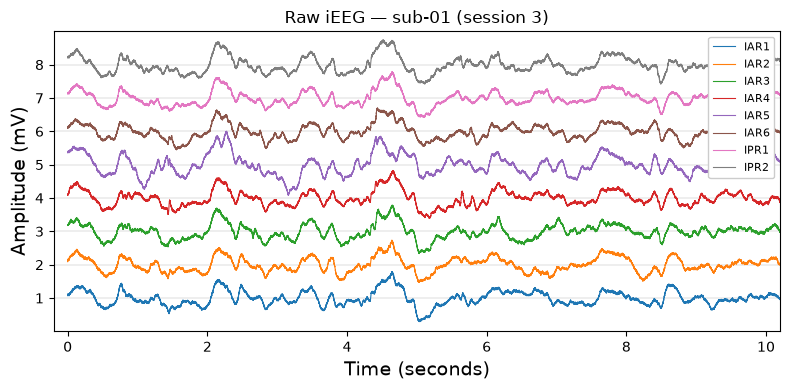

In [15]:
# VISUALIZE RAW SIGNALS FOR SELECTED CHANNELS

# Select the signals of one of the sessions of first participant
session = 3  #  0 - 27 
signals = dataset[session]
# Extract temporal sampling and channel names from the data
timepoints = signals.data['time'].values
channel_labels = signals.data["space"].values

# Plot the figure
n_show_channels = 8
plt.figure(figsize=(8,4))
for i in range(n_show_channels):
    plt.plot( timepoints, i+1 + 1000 * signals.data[i], lw=0.8, label=channel_labels[i] )

plt.xlim(-0.2,10.2)
plt.ylim(0, n_show_channels + 1)
plt.yticks( np.arange(1,n_show_channels+1), np.arange(1,n_show_channels+1) )
plt.xlabel("Time (seconds)")
plt.ylabel( "Amplitude (mV)" )
plt.title( f"Raw iEEG — sub-01 (session {session})" )
plt.legend(loc="upper right", fontsize=8, frameon=True, framealpha=1)
plt.grid(axis='y', lw = 0.3, zorder=0)
plt.tight_layout()



## CONTINUE HERE !!!!

<span style="color:darkred">
TODO FROM HERE:
    
Next steps to finish this notebook:
- Notch filtering (50 Hz)
- Remove noise: Band-pass (0.001 – 500 Hz).
    - Show signals before and after, for some channels.
    - Compute and show the spectrogram before and after, for same channels.
- Bandpass filtering (define freq  dictionary first)
- Plot band-power of the channels (helps test BandPower() function).
</span>



## 4. Filtering and decomposing the signals

Once downloaded, we will perform some filtering ...
- Notch filtering (50 Hz)
- Remove noise: Band-pass (0.001 – 500 Hz).
    - Show signals before and after, for some channels.
    - Compute and show the spectrogram before and after, for same channels.
- Bandpass filtering (define freq  dictionary first)
- Plot band-power of the channels (helps test BandPower() function).

### 4.1 Notch Filtering

iEEG recordings are typically contaminated by **50 Hz power-line noise** (in Europe). We apply a narrow IIR notch filter at 50 Hz before any further processing. The effect is visible in the power spectral density (PSD): the 50 Hz peak should disappear after filtering.

> **Notice that** in cobrabox all feature calls return a new data object. Therefore, filtering functions return a copy of the original signals intead of filtering the data 'in-place'. For '*in-place*' application replacement of the data can be performed, e.g., `signals = cb.notch_filter(signals)`.


In [19]:
# Define some helper functions to carry out the filtering and plotting

def notch_filter(da: xr.DataArray, freq: float = 50.0, q: float = 30.0, fs: float = None) -> xr.DataArray:
    ## TODO: Re-write this function such that it filters all the signals and returns a copy of (or changes in place) the 
    ## input Data.SignalData, instead of an xarray. It is very confusing from user perspective to input a SignalData object,
    ## and to get an xarray in return, loosing the metadata of the input object.
    """Apply a notch (IIR) filter along the time axis of a DataArray."""
    b, a = iirnotch(freq, q, fs)
    return xr.apply_ufunc(lambda x: filtfilt(b, a, x, axis=0), da)


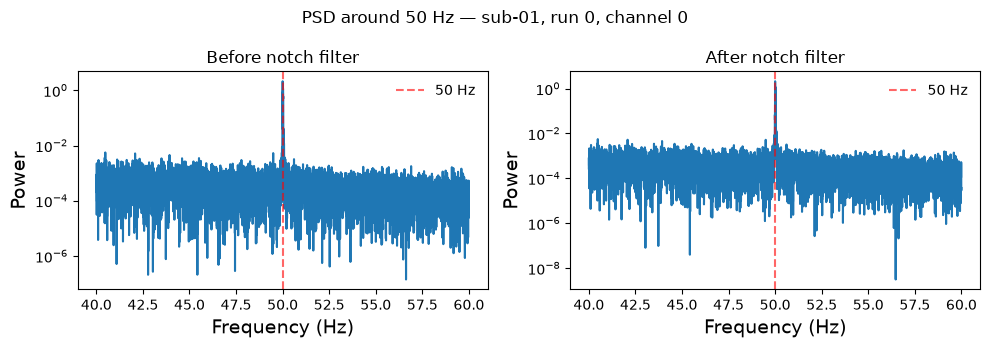

In [46]:
# APPLY A NOTCH FILTER TO REMOVE THE 50 Hz POWER-LINE PEAK AND COMPARE

# Get the original power spectral density
freqs, psd_raw = cb.power_spectral_density(signals, cutoff=500)

# Apply the notch filter (returns copy of the data)
signals_notch = cb.notch_filter(signals, f=50, q=x, ...)

# Get the new power spectral density
_, psd_notch = cb.power_spectral_density(signals_notch, cutoff=500)


## Visualise the results ###################################################################
mask = (freqs >= 30) & (freqs <= 70)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=False)
for ax, psd, title in zip(axes, [psd_raw, psd_notch], ["Before notch filter", "After notch filter"]):
    ax.semilogy(freqs[mask], psd[mask])
    ax.axvline(50, color="red", linestyle="--", alpha=0.6, label="50 Hz")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power")
    ax.set_title(title)
    ax.legend()

fig.suptitle("PSD around 50 Hz — sub-01, run 0, channel 0")
plt.tight_layout()


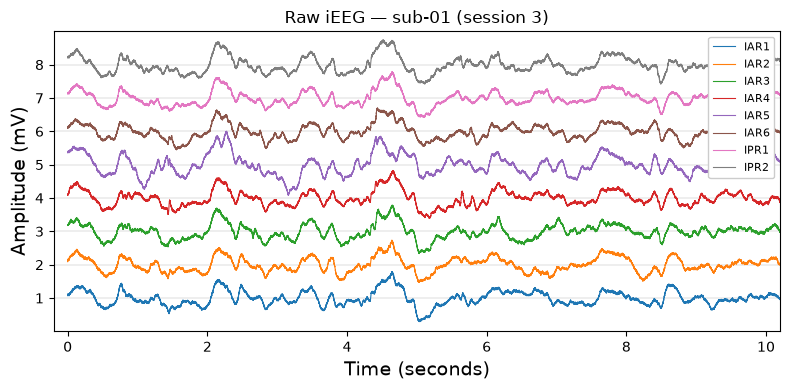

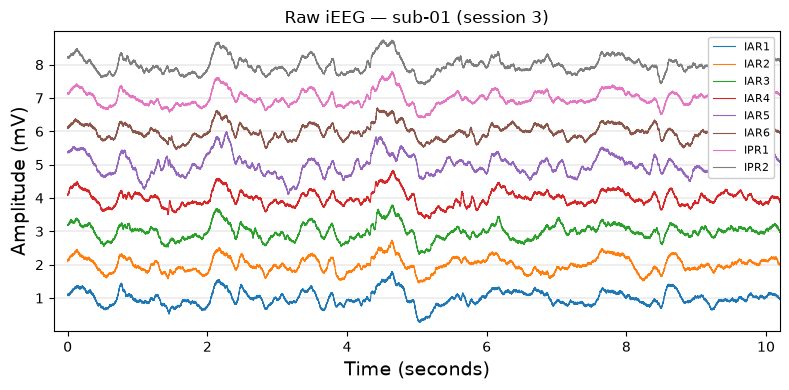

In [48]:
filtered_ch = notch_filter(signals.data, fs=signals.sampling_rate)

# Plot the figure
n_show_channels = 8
plt.figure(figsize=(8,4))
for i in range(n_show_channels):
    plt.plot( timepoints, i+1 + 1000 * signals.data[i], lw=0.8, label=channel_labels[i] )

plt.xlim(-0.2,10.2)
plt.ylim(0, n_show_channels + 1)
plt.yticks( np.arange(1,n_show_channels+1), np.arange(1,n_show_channels+1) )
plt.xlabel("Time (seconds)")
plt.ylabel( "Amplitude (mV)" )
plt.title( f"Raw iEEG — sub-01 (session {session})" )
plt.legend(loc="upper right", fontsize=8, frameon=True, framealpha=1)
plt.grid(axis='y', lw = 0.3, zorder=0)
plt.tight_layout()


# Plot the figure
n_show_channels = 8
plt.figure(figsize=(8,4))
for i in range(n_show_channels):
    plt.plot( timepoints, i+1 + 1000 * filtered_ch.data[i], lw=0.8, label=channel_labels[i] )

plt.xlim(-0.2,10.2)
plt.ylim(0, n_show_channels + 1)
plt.yticks( np.arange(1,n_show_channels+1), np.arange(1,n_show_channels+1) )
plt.xlabel("Time (seconds)")
plt.ylabel( "Amplitude (mV)" )
plt.title( f"Filtered iEEG — sub-01 (session {session})" )
plt.legend(loc="upper right", fontsize=8, frameon=True, framealpha=1)
plt.grid(axis='y', lw = 0.3, zorder=0)
plt.tight_layout()


In [ ]:
item0 = ds[0]
fs = item0.sampling_rate

raw_ch = item0.data.isel(space=0)
filtered_ch = notch_filter(item0.data, fs=fs).isel(space=0)

def compute_psd(signal, fs):
    spectrum = np.abs(np.fft.rfft(signal.values)) ** 2
    freqs = np.fft.rfftfreq(len(signal), d=1.0 / fs)
    return freqs, spectrum

freqs, psd_raw = compute_psd(raw_ch, fs)
_, psd_filt = compute_psd(filtered_ch, fs)

mask = (freqs >= 40) & (freqs <= 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, psd, title in zip(axes, [psd_raw, psd_filt], ["Before notch filter", "After notch filter"]):
    ax.semilogy(freqs[mask], psd[mask])
    ax.axvline(50, color="red", linestyle="--", alpha=0.6, label="50 Hz")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power")
    ax.set_title(title)
    ax.legend()

fig.suptitle("PSD around 50 Hz — sub-01, run 0, channel 0")
plt.tight_layout()
#plt.show()

## 6. Bipolar Montage

The **bipolar montage** subtracts adjacent unipolar contacts on the same electrode shaft
(e.g. AHR2 − AHR1 → "AHR1-AHR2"). This serves two purposes:
1. Cancels common-mode noise (e.g. reference artefacts, global slow waves)
2. Produces a more spatially localised signal, sensitive to activity between the two contacts

Only pairs where both contacts are present, not excluded, and not pipeline-rejected are
used ("valid pairs").

In [ ]:
item0 = ds[0]
fs = item0.sampling_rate
valid_pairs = get_valid_pairs(item0, "sub-01", patient_info)

print(f"Valid bipolar pairs for sub-01 ({len(valid_pairs)} total):")
for i, pair in enumerate(valid_pairs):
    print(f"  {i+1:3d}. {pair}")

demo_pair = valid_pairs[0]
ch_a, ch_b = demo_pair.split("-")

filtered_data = notch_filter(item0.data, fs=fs)
n_show = int(2.0 * fs)
t = np.arange(n_show) / fs

sig_a = filtered_data.sel(space=ch_a).isel(time=slice(0, n_show)).values
sig_b = filtered_data.sel(space=ch_b).isel(time=slice(0, n_show)).values
sig_bip = sig_a - sig_b

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for ax, signal, label in zip(axes, [sig_a, sig_b, sig_bip], [ch_a, ch_b, f"{ch_a}-{ch_b} (bipolar)"]):
    ax.plot(t, signal, lw=0.8)
    ax.set_ylabel(label, fontsize=9)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"Bipolar derivation demo — {demo_pair}")
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated the key data structures and preprocessing steps for sub-01:

- Patient metadata loaded from CSV: outcome, resected channels, pipeline exclusions
- Raw iEEG runs loaded via `cb.load_dataset`
- 50 Hz notch filter verified in the frequency domain
- Bipolar montage construction from valid unipolar pairs
- Random 3 s segment sampling strategy

**Next step:** `02_preprocessing_and_computation.ipynb` runs this pipeline for all 20 subjects
in batch, computing PDC connectivity and RC values that are saved to disk.